In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.preprocessing import StandardScaler

import numpy as np
import plotly.io as pio
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

import matplotlib.pyplot as plt

pio.renderers.default = 'vscode'

In [2]:
data = pd.read_csv("data/Measurements.csv", sep=";")
data.head(5)

,пол,"длина тела, см",длина туловища,длина ноги,"размах рук, см","масса тела, кг",окруж. груд.кл.в покое.,ширина плеч,ширина таза,обхват ягодиц
0,ж,161,48,84,160,"57,3","82,5","30,5",26,"97,5"
1,ж,"151,5",47,NaN,155,"52,4",77,37,28,85
2,м,182,53,NaN,196,71,88,42,33,90
3,м,181,54,NaN,191,84,94,47,32,96
4,м,169,51,NaN,180,"62,8",83,47,47,89


In [3]:
alias = {"М": "м", "муж": "м", "м":"м", "Ж": "ж", "жен": "ж", "ж":"ж"}

def gender_format(value: str):
    return alias[value]

data["пол"] = data["пол"].map(gender_format)
gender = data["пол"]
data["пол"].value_counts()


пол
ж    206
м     85
Name: count, dtype: int64

In [4]:
required_columns = ["длина тела, см", "масса тела, кг", "окруж. груд.кл.в покое.", "ширина плеч", "ширина таза"]

for col in required_columns:
    data[col] = data[col].astype(str).str.replace(",", ".", regex=False)

data = data.astype({col: float for col in required_columns})
data = data.dropna()
gender = data['пол']
data = data[required_columns]

In [5]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA(n_components=3)
data_pca = pca.fit_transform(data_scaled)

print(f"Объясненная дисперсия по компонентам: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

Объясненная дисперсия по компонентам: [0.65979139 0.15824488 0.1162734 ]
Суммарная объясненная дисперсия: 0.934


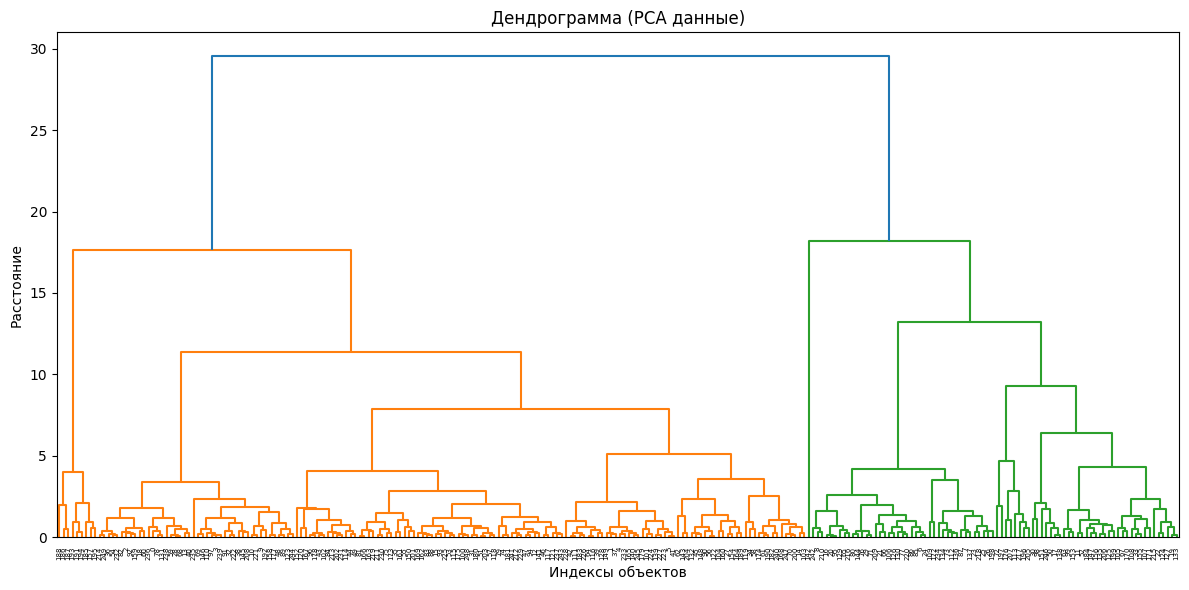

In [6]:
distances = pdist(data_pca, metric='euclidean')
linkage_matrix = linkage(distances, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, p=30, leaf_rotation=90)
plt.title('Дендрограмма (PCA данные)')
plt.xlabel('Индексы объектов')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

In [7]:
n_clusters = 5
clusters_pca = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

print(f"Количество кластеров: {n_clusters}")
print(f"Распределение по кластерам (PCA):")
for i in range(1, n_clusters + 1):
    print(f"  Кластер {i}: {np.sum(clusters_pca == i)} объектов")

Количество кластеров: 5
Распределение по кластерам (PCA):
  Кластер 1: 9 объектов
  Кластер 2: 158 объектов
  Кластер 3: 41 объектов
  Кластер 4: 41 объектов
  Кластер 5: 1 объектов


In [8]:
df_plot_pca = pd.DataFrame({
    'PC1': data_pca[:, 0],
    'PC2': data_pca[:, 1],
    'PC3': data_pca[:, 2],
    'Кластер': clusters_pca.astype(str)
})

fig = px.scatter_3d(
    df_plot_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Кластер',
    title=f'PCA + Иерархическая кластеризация (K={n_clusters})',
    labels={'PC1': 'Главная компонента 1',
            'PC2': 'Главная компонента 2',
            'PC3': 'Главная компонента 3'},
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(width=800, height=600)
fig.show()

In [9]:
cross_tab_pca = pd.crosstab(clusters_pca, gender)
print("Таблица пересечения кластеров (PCA) с полом:")
print(cross_tab_pca)

# Вычисление процента пересечения
print("\nОценка пересечения:")
for cluster in range(1, n_clusters + 1):
    cluster_data = cross_tab_pca.loc[cluster]
    total = cluster_data.sum()
    if total > 0:
        male_pct = (cluster_data.get('м', 0) / total) * 100
        female_pct = (cluster_data.get('ж', 0) / total) * 100
        print(f"Кластер {cluster}: {male_pct:.1f}% мужчин, {female_pct:.1f}% женщин")

Таблица пересечения кластеров (PCA) с полом:
пол      ж   м
row_0         
1        4   5
2      151   7
3        7  34
4       15  26
5        1   0

Оценка пересечения:
Кластер 1: 55.6% мужчин, 44.4% женщин
Кластер 2: 4.4% мужчин, 95.6% женщин
Кластер 3: 82.9% мужчин, 17.1% женщин
Кластер 4: 63.4% мужчин, 36.6% женщин
Кластер 5: 0.0% мужчин, 100.0% женщин


In [10]:
data_scaled_raw = StandardScaler().fit_transform(data)

# Вычисляем расстояния
distances_raw = pdist(data_scaled_raw, metric='euclidean')

# Кластеризация
linkage_matrix_raw = linkage(distances_raw, method='ward')

# Формируем кластеры
clusters_raw = fcluster(linkage_matrix_raw, n_clusters, criterion='maxclust')

print(f"Кластеризация без PCA (K={n_clusters})")
print("Распределение по кластерам:")
for i in range(1, n_clusters + 1):
    print(f"  Кластер {i}: {np.sum(clusters_raw == i)} объектов")

Кластеризация без PCA (K=5)
Распределение по кластерам:
  Кластер 1: 9 объектов
  Кластер 2: 138 объектов
  Кластер 3: 12 объектов
  Кластер 4: 90 объектов
  Кластер 5: 1 объектов


In [11]:
pca_viz = PCA(n_components=3)
data_pca_viz = pca_viz.fit_transform(data_scaled_raw)

df_plot_raw = pd.DataFrame({
    'PC1': data_pca_viz[:, 0],
    'PC2': data_pca_viz[:, 1],
    'PC3': data_pca_viz[:, 2],
    'Кластер': clusters_raw.astype(str)
})

fig = px.scatter_3d(
    df_plot_raw,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Кластер',
    title=f'Кластеризация без PCA (K={n_clusters})',
    labels={'PC1': 'Главная компонента 1',
            'PC2': 'Главная компонента 2',
            'PC3': 'Главная компонента 3'},
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(width=800, height=600)
fig.show()

In [12]:
cross_tab_raw = pd.crosstab(clusters_raw, gender)
print("Таблица пересечения кластеров (без PCA) с полом:")
print(cross_tab_raw)

print("\nОценка пересечения:")
for cluster in range(1, n_clusters + 1):
    cluster_data = cross_tab_raw.loc[cluster]
    total = cluster_data.sum()
    if total > 0:
        male_pct = (cluster_data.get('м', 0) / total) * 100
        female_pct = (cluster_data.get('ж', 0) / total) * 100
        print(f"Кластер {cluster}: {male_pct:.1f}% мужчин, {female_pct:.1f}% женщин")

Таблица пересечения кластеров (без PCA) с полом:
пол      ж   м
row_0         
1        4   5
2      129   9
3        0  12
4       44  46
5        1   0

Оценка пересечения:
Кластер 1: 55.6% мужчин, 44.4% женщин
Кластер 2: 6.5% мужчин, 93.5% женщин
Кластер 3: 100.0% мужчин, 0.0% женщин
Кластер 4: 51.1% мужчин, 48.9% женщин
Кластер 5: 0.0% мужчин, 100.0% женщин


In [15]:
print("\n1. Качество кластеризации (внутрикластерная дисперсия):")
from scipy.spatial.distance import cdist

# Для PCA данных
centroids_pca = np.array([data_pca[clusters_pca == i].mean(axis=0) for i in range(1, n_clusters + 1)])
inertia_pca = sum(np.sum((data_pca[clusters_pca == i] - centroids_pca[i-1])**2) for i in range(1, n_clusters + 1))

# Для исходных данных
centroids_raw = np.array([data_scaled_raw[clusters_raw == i].mean(axis=0) for i in range(1, n_clusters + 1)])
inertia_raw = sum(np.sum((data_scaled_raw[clusters_raw == i] - centroids_raw[i-1])**2) for i in range(1, n_clusters + 1))

print(f"Сумма квадратов расстояний (PCA): {inertia_pca:.2f}")
print(f"Сумма квадратов расстояний (без PCA): {inertia_raw:.2f}")

print("\n2. Чистота кластеров (по полу):")
def cluster_purity(cross_tab):
    purity = 0
    total = cross_tab.sum().sum()
    for cluster in cross_tab.index:
        purity += cross_tab.loc[cluster].max()
    return purity / total

purity_pca = cluster_purity(cross_tab_pca)
purity_raw = cluster_purity(cross_tab_raw)

print(f"Чистота кластеров (PCA): {purity_pca:.2%}")
print(f"Чистота кластеров (без PCA): {purity_raw:.2%}")


1. Качество кластеризации (внутрикластерная дисперсия):
Сумма квадратов расстояний (PCA): 323.41
Сумма квадратов расстояний (без PCA): 385.82

2. Чистота кластеров (по полу):
Чистота кластеров (PCA): 86.80%
Чистота кластеров (без PCA): 77.20%


3. Вывод:
- Кластеризация на PCA данных дала более компактные кластеры
- PCA улучшила разделение по полу